In [3]:
import platform
from pathlib import Path

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd

from vascular_superenhancement.utils.path_config import load_path_config, _PROJECT_ROOT

config_name = "local_mac" if platform.system() == "Darwin" else "all_patients"
pc = load_path_config(config_name)

PATIENT_DATA_DIR = pc.working_dir / "patient_data"
DS_FOLDER = "downsampled_full_fov_128x128x64_crop-17.5"

splits_df = pd.read_csv(_PROJECT_ROOT / "splits" / "splits_01-15-26.csv")
patients_df = splits_df[splits_df["split"].isin(["train", "validation", "test"])].copy()
patients_df = patients_df.sort_values(["split", "patient_id"]).reset_index(drop=True)

print(f"Non-skipped patients: {len(patients_df)}")

Non-skipped patients: 209


[1/209] Balboloop OK
[2/209] Biswifo OK
[3/209] Bomatog OK
[4/209] Boochuto OK
[5/209] Boumorim OK
[6/209] Bovutou OK
[7/209] Cadotueg OK
[8/209] Detodu OK
[9/209] Diecudey OK
[10/209] Diepami OK
[11/209] Diequipi OK
[12/209] Dithigog OK
[13/209] Dublafer OK
[14/209] Dujomal OK
[15/209] Elagieg OK
[16/209] Golotag OK
[17/209] Grequafie OK
[18/209] Gueshifa OK
[19/209] Kuquelok OK
[20/209] Oduskueb OK
[21/209] Quetode OK
[22/209] Runusath OK
[23/209] Sepigoo OK
[24/209] Stonscuetof OK
[25/209] Suquepog OK
[26/209] Tercippun OK
[27/209] Tiepolem OK
[28/209] Tisupey OK
[29/209] Amifer OK
[30/209] Aruborn OK
[31/209] Asonlig OK
[32/209] Badiswu OK
[33/209] Bibathot OK
[34/209] Bogeebo OK
[35/209] Boudubat OK
[36/209] Burapo OK
[37/209] Butiswu OK
[38/209] Cadedag OK
[39/209] Cefaru OK
[40/209] Cemuquey OK
[41/209] Ceriba OK
[42/209] Ceyebum OK
SKIP Coosimo: no downsampled dir
[44/209] Cornuefor OK
[45/209] Crutaswo OK
[46/209] Dalibul OK
[47/209] Dapafem OK
[48/209] Datokif OK
[49/209] Des

KeyboardInterrupt: 

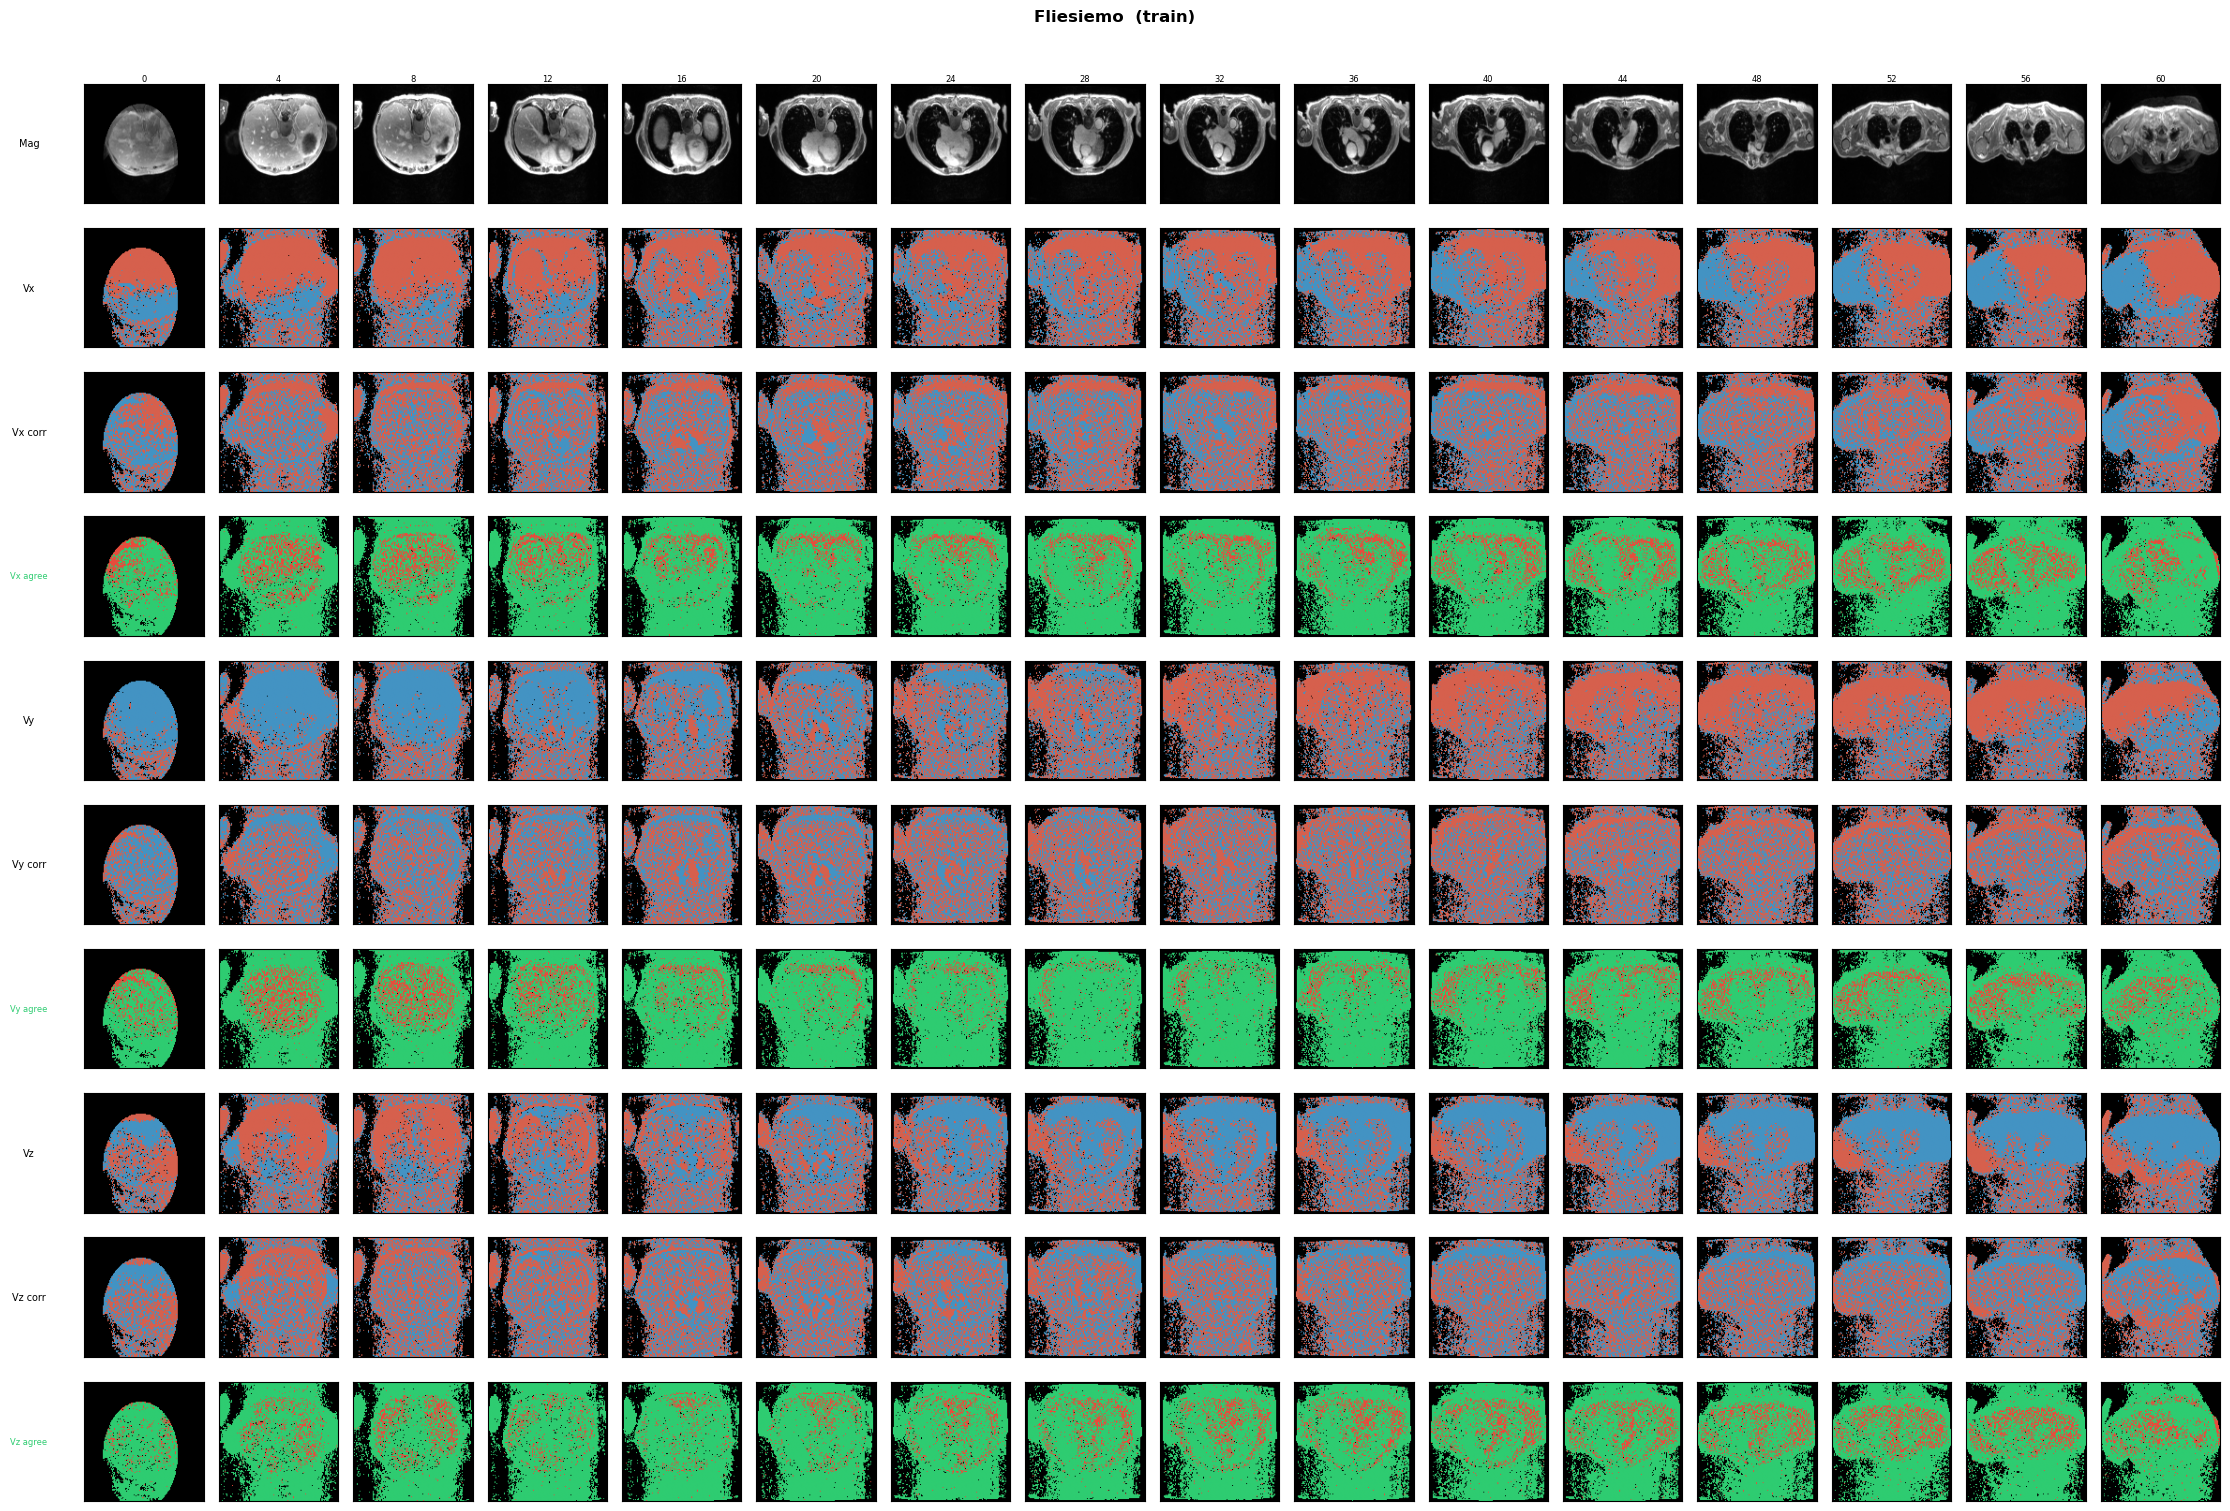

In [4]:
OUTPUT_DIR = Path("velocity_sign_check_images")
OUTPUT_DIR.mkdir(exist_ok=True)

# Sign colors: blue = negative, black = masked/zero, red = positive
SIGN_CMAP = mcolors.ListedColormap(["#4393c3", "black", "#d6604d"])
SIGN_NORM = mcolors.BoundaryNorm([-1.5, -0.5, 0.5, 1.5], SIGN_CMAP.N)

# Agreement colors: green = agree, red = disagree, black = masked
AGREE_CMAP = mcolors.ListedColormap(["black", "#e74c3c", "#2ecc71"])
AGREE_NORM = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], AGREE_CMAP.N)

VEL_PAIRS = [
    ("4d_flow_vx", "4d_flow_vx_corr", "Vx"),
    ("4d_flow_vy", "4d_flow_vy_corr", "Vy"),
    ("4d_flow_vz", "4d_flow_vz_corr", "Vz"),
]

MAG_THRESH_PCTL = 15  # mask out voxels below this percentile of magnitude


def masked_sign(vol: np.ndarray, mask: np.ndarray) -> np.ndarray:
    s = np.sign(vol)
    s[~mask] = 0
    return s


def sign_agreement(sign_a: np.ndarray, sign_b: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """2 = agree, 1 = disagree, 0 = masked."""
    out = np.zeros_like(sign_a, dtype=np.int8)
    both_nonzero = mask & (sign_a != 0) & (sign_b != 0)
    out[both_nonzero & (sign_a == sign_b)] = 2   # agree
    out[both_nonzero & (sign_a != sign_b)] = 1   # disagree
    return out


for i, (_, row) in enumerate(patients_df.iterrows()):
    pid = row["patient_id"]
    split = row["split"]
    ds_root = PATIENT_DATA_DIR / pid / "nifti" / DS_FOLDER

    if not ds_root.exists():
        print(f"SKIP {pid}: no downsampled dir")
        continue

    mag_path = ds_root / "4d_flow_mag" / f"4d_flow_mag_{pid}_frame_00.nii.gz"
    if not mag_path.exists():
        print(f"SKIP {pid}: no mag")
        continue

    mag_vol = nib.load(str(mag_path)).get_fdata(dtype=np.float32)
    n_slices = mag_vol.shape[2]
    mag_thresh = np.percentile(mag_vol[mag_vol > 0], MAG_THRESH_PCTL) if np.any(mag_vol > 0) else 0
    mag_mask = mag_vol > mag_thresh

    slice_indices = list(range(0, n_slices, 4))
    n_cols = len(slice_indices)

    # Rows: mag, then for each component: uncorr sign, corr sign, agreement
    # 1 (mag) + 3 components * 3 rows = 10 rows
    n_rows = 1 + len(VEL_PAIRS) * 3

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.4 * n_cols, 1.5 * n_rows))
    fig.suptitle(f"{pid}  ({split})", fontsize=12, fontweight="bold", y=1.01)

    # Row 0: magnitude
    vmax_mag = np.percentile(mag_vol, 99)
    for c, si in enumerate(slice_indices):
        ax = axes[0, c]
        ax.imshow(mag_vol[:, :, si].T, origin="lower", cmap="gray", vmin=0, vmax=vmax_mag, aspect="equal")
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"{si}", fontsize=6, pad=2)
    axes[0, 0].set_ylabel("Mag", fontsize=7, rotation=0, labelpad=40, va="center")

    for p, (uncorr_sub, corr_sub, label) in enumerate(VEL_PAIRS):
        uncorr_path = ds_root / uncorr_sub / f"{uncorr_sub}_{pid}_frame_00.nii.gz"
        corr_path = ds_root / corr_sub / f"{corr_sub}_{pid}_frame_00.nii.gz"

        base_row = 1 + p * 3

        if not uncorr_path.exists() or not corr_path.exists():
            for dr in range(3):
                for c in range(n_cols):
                    axes[base_row + dr, c].set_axis_off()
            axes[base_row, 0].text(0.5, 0.5, f"{label}\nMISSING", ha="center", va="center",
                                   transform=axes[base_row, 0].transAxes, fontsize=7)
            continue

        uncorr = nib.load(str(uncorr_path)).get_fdata(dtype=np.float32)
        corr = nib.load(str(corr_path)).get_fdata(dtype=np.float32)

        s_uncorr = masked_sign(uncorr, mag_mask)
        s_corr = masked_sign(corr, mag_mask)
        agree = sign_agreement(s_uncorr, s_corr, mag_mask)

        for c, si in enumerate(slice_indices):
            for dr, (data, cmap, norm) in enumerate([
                (s_uncorr[:, :, si].T, SIGN_CMAP, SIGN_NORM),
                (s_corr[:, :, si].T,   SIGN_CMAP, SIGN_NORM),
                (agree[:, :, si].T,    AGREE_CMAP, AGREE_NORM),
            ]):
                ax = axes[base_row + dr, c]
                ax.imshow(data, origin="lower", cmap=cmap, norm=norm, aspect="equal")
                ax.set_xticks([]); ax.set_yticks([])

        axes[base_row, 0].set_ylabel(label, fontsize=7, rotation=0, labelpad=40, va="center")
        axes[base_row + 1, 0].set_ylabel(f"{label} corr", fontsize=7, rotation=0, labelpad=40, va="center")
        axes[base_row + 2, 0].set_ylabel(f"{label} agree", fontsize=6, rotation=0, labelpad=40, va="center",
                                          color="#2ecc71")

    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / f"{split}_{pid}.png", dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"[{i+1}/{len(patients_df)}] {pid} OK")

print(f"\nDone. Images saved to {OUTPUT_DIR.resolve()}")